# Imports

In [1]:
from pathlib import Path
import math
import os
import sys

import torch
from torch import Tensor
from torchvision.transforms import GaussianBlur
from torchvision.transforms.functional import gaussian_blur
import numpy as np
import matplotlib.pyplot as plt

import config

PROJECT_ROOT = Path(os.path.abspath(os.pardir))
sys.path.append(str(PROJECT_ROOT))

from utils.checkpoint import load_checkpoint
from utils.data import get_dataloaders, get_img_from_loader, get_datasets
from utils.uncertainty import mc_predict, quantify_uncertainties

from models.lenet import Net as LeNet
from config import Config, load_config

In [14]:
from torchvision.datasets import MNIST, EMNIST, VisionDataset

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

emnist_letters_config = load_config(str(PROJECT_ROOT / "configs" / "emnist-letters" / "lenet_baseline.yaml"))

# Model
emnist_model = LeNet(
    prior_sigma1=emnist_letters_config.prior.sigma1,
    prior_sigma2=emnist_letters_config.prior.sigma2,
    prior_pi=emnist_letters_config.prior.pi,
    num_classes=emnist_letters_config.model.num_classes,
).to(device)

emnist_checkpoint = (
    PROJECT_ROOT
    / "runs"
    / "lenet_emnist-letters_baseline"
    / "checkpoints"
    / "last.pt"
)

# Load weights
load_checkpoint(str(emnist_checkpoint), model=emnist_model, device=device)

Checkpoint loaded from /home/qosquo/Git/bayes_nn/runs/lenet_emnist-letters_baseline/checkpoints/last.pt at epoch 80.


{'epoch': 80,
 'model_state_dict': OrderedDict([('conv1.mu',
               tensor([[[[ 0.0431,  0.1438,  0.1100,  0.4969,  0.3237],
                         [-0.0451, -0.0169,  0.2923,  0.1029,  0.4169],
                         [-0.2100, -0.1010,  0.0316,  0.1356, -0.0351],
                         [-0.1638, -0.2003, -0.1173, -0.3303, -0.0640],
                         [-0.1560, -0.0996, -0.2473, -0.1799, -0.1403]]],
               
               
                       [[[ 0.1353,  0.0676,  0.1759,  0.1238,  0.0651],
                         [-0.0532, -0.1497, -0.0120, -0.0628,  0.0115],
                         [-0.0412, -0.3255, -0.2043,  0.0503,  0.2537],
                         [-0.4938, -0.5017, -0.0083,  0.3536,  0.1079],
                         [-0.2209, -0.0671,  0.0579,  0.0372,  0.1365]]],
               
               
                       [[[-0.0279,  0.2727,  0.2952,  0.2158, -0.1095],
                         [ 0.0900,  0.0820,  0.3948,  0.0368, -0.0608],
       

In [3]:
emnist10_config = load_config(str(PROJECT_ROOT / "configs" / "emnist-letters-10" / "lenet_easy.yaml"))
emnist10_model = LeNet(
    prior_sigma1=emnist10_config.prior.sigma1,
    prior_sigma2=emnist10_config.prior.sigma2,
    prior_pi=emnist10_config.prior.pi,
    num_classes=emnist10_config.model.num_classes,
).to(device)

emnist10_checkpoint = (
    PROJECT_ROOT
    / "runs"
    / "lenet_emnist-letters-10_baseline"
    / "checkpoints"
    / "last.pt"
)

load_checkpoint(str(emnist10_checkpoint), model=emnist10_model, device=device)

Checkpoint loaded from /home/qosquo/Git/bayes_nn/runs/lenet_emnist-letters-10_baseline/checkpoints/last.pt at epoch 80.


{'epoch': 80,
 'model_state_dict': OrderedDict([('conv1.mu',
               tensor([[[[ 0.1871,  0.2079,  0.2544,  0.0785,  0.1827],
                         [ 0.1731,  0.0688,  0.1379,  0.1785,  0.0886],
                         [ 0.2504,  0.2009,  0.0797,  0.1730,  0.1648],
                         [ 0.1592,  0.1634,  0.0853,  0.2108,  0.2055],
                         [ 0.1313, -0.1195,  0.0083, -0.0218, -0.0738]]],
               
               
                       [[[ 0.1828,  0.0017, -0.0647,  0.0247,  0.1368],
                         [-0.0843, -0.1757, -0.1381, -0.0942,  0.0314],
                         [-0.2129, -0.2611, -0.1565, -0.1766,  0.0861],
                         [-0.1097, -0.3480, -0.1173, -0.0029,  0.1026],
                         [-0.2030, -0.0044,  0.0168,  0.0359,  0.2284]]],
               
               
                       [[[-0.1746, -0.1988,  0.2528,  0.2342,  0.0795],
                         [-0.2931, -0.0565,  0.3044,  0.2133,  0.0906],
       

In [4]:
emnist10_def_config = load_config(str(PROJECT_ROOT / "configs" / "emnist-letters-10" / "lenet.yaml"))
emnist10_def_model = LeNet(
    prior_sigma1=emnist10_def_config.prior.sigma1,
    prior_sigma2=emnist10_def_config.prior.sigma2,
    prior_pi=emnist10_def_config.prior.pi,
    num_classes=emnist10_def_config.model.num_classes,
).to(device)

emnist10_def_checkpoint = (
    PROJECT_ROOT
    / "runs"
    / "lenet_emnist-letters-10_default"
    / "checkpoints"
    / "last.pt"
)

load_checkpoint(str(emnist10_def_checkpoint), model=emnist10_def_model, device=device)

Checkpoint loaded from /home/qosquo/Git/bayes_nn/runs/lenet_emnist-letters-10_default/checkpoints/last.pt at epoch 81.


{'epoch': 81,
 'model_state_dict': OrderedDict([('conv1.mu',
               tensor([[[[ 0.2349,  0.1644,  0.1901,  0.0017,  0.0713],
                         [ 0.2751,  0.1190,  0.1854,  0.1756,  0.0483],
                         [ 0.2631,  0.2409,  0.1533,  0.2192,  0.2204],
                         [ 0.0197,  0.1091,  0.1175,  0.2979,  0.3025],
                         [ 0.0210, -0.1333,  0.0501,  0.0358, -0.0505]]],
               
               
                       [[[ 0.1301, -0.0784, -0.0961,  0.0380,  0.1379],
                         [-0.0868, -0.2625, -0.1346, -0.0372,  0.0500],
                         [-0.2015, -0.3185, -0.1055, -0.1007,  0.1150],
                         [-0.0991, -0.3650, -0.0579,  0.0633,  0.1111],
                         [-0.1917, -0.0153,  0.0640,  0.0790,  0.2190]]],
               
               
                       [[[-0.1802, -0.2003,  0.2521,  0.2407,  0.1732],
                         [-0.3147, -0.0823,  0.2576,  0.1793,  0.1917],
       

In [5]:
emnist18_config = load_config(str(PROJECT_ROOT / "configs" / "emnist-letters-18" / "lenet.yaml"))
emnist18_model = LeNet(
    prior_sigma1=emnist18_config.prior.sigma1,
    prior_sigma2=emnist18_config.prior.sigma2,
    prior_pi=emnist18_config.prior.pi,
    num_classes=emnist18_config.model.num_classes,
).to(device)

emnist18_checkpoint = (
    PROJECT_ROOT
    / "runs"
    / "lenet_emnist-letters-18"
    / "checkpoints"
    / "last.pt"
)

load_checkpoint(str(emnist18_checkpoint), model=emnist18_model, device=device)

Checkpoint loaded from /home/qosquo/Git/bayes_nn/runs/lenet_emnist-letters-18/checkpoints/last.pt at epoch 79.


{'epoch': 79,
 'model_state_dict': OrderedDict([('conv1.mu',
               tensor([[[[ 0.0475,  0.1401,  0.1381,  0.2481,  0.2388],
                         [-0.1073, -0.1445, -0.0211,  0.1353,  0.2501],
                         [-0.2854, -0.2017, -0.0591, -0.1254,  0.2073],
                         [-0.1771, -0.3135, -0.1050,  0.0005,  0.2445],
                         [-0.1731, -0.3514, -0.1521, -0.1066,  0.2192]]],
               
               
                       [[[ 0.0754,  0.0789, -0.0150,  0.1443,  0.3148],
                         [ 0.1258,  0.1169,  0.1223, -0.0935, -0.1140],
                         [ 0.0838, -0.4368, -0.0631,  0.1094, -0.2362],
                         [-0.2561, -0.3804, -0.3325, -0.3262, -0.4967],
                         [-0.0789, -0.3501, -0.1467, -0.2295, -0.3985]]],
               
               
                       [[[ 0.2268,  0.3996,  0.2382,  0.1199,  0.0454],
                         [ 0.1893,  0.1984,  0.1272, -0.1914, -0.1329],
       

In [6]:
mnist_config = load_config(str(PROJECT_ROOT / "configs" / "mnist" / "lenet_baseline.yaml"))
mnist_model = LeNet(
    prior_sigma1=mnist_config.prior.sigma1,
    prior_sigma2=mnist_config.prior.sigma2,
    prior_pi=mnist_config.prior.pi,
    num_classes=mnist_config.model.num_classes,
).to(device)

mnist_checkpoint = (
    PROJECT_ROOT
    / "runs"
    / "lenet_mnist_baseline"
    / "checkpoints"
    / "last.pt"
)

load_checkpoint(str(mnist_checkpoint), model=mnist_model, device=device)

Checkpoint loaded from /home/qosquo/Git/bayes_nn/runs/lenet_mnist_baseline/checkpoints/last.pt at epoch 199.


{'epoch': 199,
 'model_state_dict': OrderedDict([('conv1.mu',
               tensor([[[[-0.0025, -0.2455, -0.1540, -0.1311, -0.2081],
                         [-0.3667, -0.1137, -0.0697, -0.0435, -0.1546],
                         [-0.3023,  0.0947, -0.1128,  0.1892, -0.1983],
                         [ 0.0702,  0.1064,  0.3590,  0.1546,  0.3224],
                         [ 0.2760,  0.3927,  0.2583,  0.2841,  0.3877]]],
               
               
                       [[[ 0.2365,  0.1012, -0.0870, -0.3085, -0.2910],
                         [ 0.1144,  0.0624, -0.1199, -0.2841, -0.0412],
                         [ 0.0808,  0.3196,  0.1970,  0.1296, -0.0098],
                         [ 0.0840,  0.1477,  0.3116,  0.1183,  0.2050],
                         [-0.1819, -0.0513, -0.0232,  0.0605,  0.1578]]],
               
               
                       [[[ 0.0300,  0.0997, -0.1955, -0.3049, -0.2543],
                         [ 0.1880, -0.2065, -0.2967, -0.2729, -0.0302],
      

# Preliminary functions

In [7]:
from typing import Callable
from torchvision import transforms

def make_loader(
    dataset_cls: Callable[..., VisionDataset],
    *,
    dataset_kwargs: dict | None=None,
    dataset_transforms: Callable[..., VisionDataset] | None=None,
    kernel_size: int = 1,
    batch_size: int = 14,
):
    dataset_kwargs = dataset_kwargs or {}

    tfms = []

    if kernel_size > 1:
        tfms.append(GaussianBlur(kernel_size))

    _, test_dataset = get_datasets(
        root=str(PROJECT_ROOT / "data"),
        dataset=dataset_cls,
        download=True,
        normalize=True,
        extra_transforms=tfms,
        dataset_kwargs=dataset_kwargs
    )

    test_dataset = dataset_transforms(test_dataset) if dataset_transforms else test_dataset

    return DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=1,
    )

In [8]:
from tqdm import tqdm
from torch.utils.data import DataLoader
from typing import Callable, Any

from utils.uncertainty import mc_predict, quantify_uncertainties

def evaluate_with_blurs(
    model: torch.nn.Module,
    dataset_cls: Callable[..., VisionDataset],
    dataset_kwargs: dict | None,
    dataset_transforms: Callable[..., VisionDataset] | None,
    kernel_sizes: list[int],
    device: torch.device,
    mc_samples: int = 10,
    desc: str = "",
) -> dict[int, tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]]:
    """
    Returns dict with keys as kernel sizes and values as tuples of:
    (predictions, total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty)
    """
    res = {}

    pbar = tqdm(kernel_sizes, desc=desc)

    for ks in pbar:
        pbar.set_description(f"{desc} - Kernel {ks}")
        k_blur_preds, k_blur_tus, k_blur_aus, k_blur_eus = [], [], [], []

        loader = make_loader(
            dataset_cls,
            dataset_kwargs=dataset_kwargs,
            dataset_transforms=dataset_transforms,
            kernel_size=ks,
        )

        for x, y in loader:
            x, y = x.to(device), y.to(device)
            mc_preds = mc_predict(model, x, mc_samples=mc_samples)
            tu, au, eu = quantify_uncertainties(mc_preds)
            k_blur_preds.append(mc_preds.mean(dim=0))
            k_blur_tus.append(tu)
            k_blur_aus.append(au)
            k_blur_eus.append(eu)

        k_blur_preds = torch.cat(k_blur_preds, dim=0)
        k_blur_tus = torch.cat(k_blur_tus, dim=0)
        k_blur_aus = torch.cat(k_blur_aus, dim=0)
        k_blur_eus = torch.cat(k_blur_eus, dim=0)

        res[ks] = (k_blur_preds, k_blur_tus, k_blur_aus, k_blur_eus)

    return res

# Evaluation with Gaussian Blur

In [9]:
_d = np.load("npz/emnist-letters_subsets_gaussian_blur_correlation.npz", allow_pickle=True)
T = _d["mc_samples"]
kernel_sizes = _d["kernel_sizes"]
emnist_evals = _d["emnist_evals"].item()
emnist10_evals = _d["emnist10_evals"].item()
emnist10_def_evals = _d["emnist10_def_evals"].item()
emnist18_evals = _d["emnist18_evals"].item()
mnist_evals = _d["mnist_evals"].item()

In [10]:
T = 10
kernel_sizes = [1, 3, 5, 7, 9]

In [12]:
from config import build_transform

target10_transform = lambda y: {i: j for i, j in zip([1, 3, 5, 8, 10, 11, 16, 20, 23, 24], range(10))}[y]
target10_def_transform = lambda y: {i: j for i, j in zip(range(1, 11), range(10))}[y]
target18_transform = lambda y: {i: j for i, j in zip(range(1, 19), range(18))}[y]



In [ ]:
emnist_evals = evaluate_with_blurs(
    emnist_model,
    EMNIST,
    {"split": "letters"},
    None,
    kernel_sizes, device, T,
    desc="EMNIST Gaussian Blur",
)

In [ ]:
emnist10_evals = evaluate_with_blurs(
    emnist10_model,
    EMNIST,
    {"split": "letters", "target_transform": target10_transform},
    build_transform(emnist10_config.data.dataset_transform),
    kernel_sizes, device, T,
    desc="EMNIST-10 Gaussian Blur",
)

In [10]:
emnist10_def_evals = evaluate_with_blurs(
    emnist10_def_model,
    EMNIST,
    {"split": "letters", "target_transform": target10_def_transform},
    build_transform(emnist10_def_config.data.dataset_transform),
    kernel_sizes, device, T,
    desc="EMNIST-10 Default Gaussian Blur",
)

EMNIST-10 Default Gaussian Blur - Kernel 1:   0%|          | 0/5 [00:00<?, ?it/s]/home/qosquo/Git/bayes_nn/utils/data.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.tensor(getattr(dataset, "targets"))
EMNIST-10 Default Gaussian Blur - Kernel 9: 100%|██████████| 5/5 [03:06<00:00, 37.35s/it]


In [19]:
emnist18_evals = evaluate_with_blurs(
    emnist18_model,
    EMNIST,
    {"split": "letters", "target_transform": target18_transform},
    build_transform(emnist18_config.data.dataset_transform),
    kernel_sizes, device, T,
    desc="EMNIST-18 Gaussian Blur",
)

EMNIST-18 Gaussian Blur - Kernel 9: 100%|██████████| 5/5 [05:35<00:00, 67.16s/it]


In [24]:
from torchvision.datasets import MNIST

mnist_evals = evaluate_with_blurs(
    mnist_model,
    MNIST,
    None,
    None,
    kernel_sizes, device, T,
    desc="MNIST Gaussian Blur",
)

MNIST Gaussian Blur - Kernel 9: 100%|██████████| 5/5 [03:50<00:00, 46.11s/it]


In [25]:
np.savez(
    "npz/emnist-letters_subsets_gaussian_blur_correlation.npz",
    kernel_sizes=kernel_sizes,
    mc_samples=T,
    emnist_evals=emnist_evals,
    emnist10_evals=emnist10_evals,
    emnist10_def_evals=emnist10_def_evals,
    emnist18_evals=emnist18_evals,
    mnist_evals=mnist_evals
)

# Корреляция между предсказанной уверенностью и неопределенностью

In [15]:
import numpy as np

def calculate_correlations(probs: torch.Tensor, total_uncs: torch.Tensor, labels: torch.Tensor) -> tuple[float, float]:
    pred_conf = probs[torch.arange(len(probs)), probs.argmax(dim=1)].cpu().numpy()
    true_conf = probs[torch.arange(len(labels)), labels].cpu().numpy()
    total_uncs = total_uncs.diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy()
    return np.corrcoef(pred_conf, total_uncs)[0, 1], np.corrcoef(true_conf, total_uncs)[0, 1]

emnist_labels = torch.cat([y for _, y in make_loader(EMNIST, dataset_kwargs={"split": "letters"})]).to(device)
emnist_correlations_true = [calculate_correlations(emnist_evals[ks][0], emnist_evals[ks][1], emnist_labels)[1] for ks in kernel_sizes]

emnist10_labels = torch.cat([y for _, y in make_loader(EMNIST,
                                                       dataset_kwargs={"split": "letters", "target_transform": target10_transform},
                                                       dataset_transforms=build_transform(emnist10_config.data.dataset_transform))]).to(device)
emnist10_correlations_true = [calculate_correlations(emnist10_evals[ks][0], emnist10_evals[ks][1], emnist10_labels)[1] for ks in kernel_sizes]

emnist10_def_labels = torch.cat([y for _, y in make_loader(EMNIST,
                                                           dataset_kwargs={"split": "letters", "target_transform": target10_def_transform},
                                                           dataset_transforms=build_transform(emnist10_def_config.data.dataset_transform))]).to(device)
emnist10_def_correlations_true = [calculate_correlations(emnist10_def_evals[ks][0],
                                                         emnist10_def_evals[ks][1],
                                                         emnist10_def_labels)[1] for ks in kernel_sizes]

emnist18_labels = torch.cat([y for _, y in make_loader(EMNIST,
                                                       dataset_kwargs={"split": "letters", "target_transform": target18_transform},
                                                       dataset_transforms=build_transform(emnist18_config.data.dataset_transform))]).to(device)
emnist18_correlations_true = [calculate_correlations(emnist18_evals[ks][0], emnist18_evals[ks][1], emnist18_labels)[1] for ks in kernel_sizes]

mnist_labels = torch.cat([y for _, y in make_loader(MNIST)]).to(device)
mnist_correlations_true = [calculate_correlations(mnist_evals[ks][0], mnist_evals[ks][1], mnist_labels)[1] for ks in kernel_sizes]


In [16]:
emnist_labels = torch.cat([y for _, y in make_loader(EMNIST, dataset_kwargs={"split": "letters"})]).to(device)
emnist_correlations_pred = [calculate_correlations(emnist_evals[ks][0], emnist_evals[ks][1], emnist_labels)[0] for ks in kernel_sizes]

emnist10_correlations_pred = [calculate_correlations(emnist10_evals[ks][0], emnist10_evals[ks][1], emnist10_labels)[0] for ks in kernel_sizes]
emnist10_def_correlations_pred = [calculate_correlations(emnist10_def_evals[ks][0],
                                                         emnist10_def_evals[ks][1],
                                                         emnist10_def_labels)[0] for ks in kernel_sizes]
emnist18_correlations_pred = [calculate_correlations(emnist18_evals[ks][0], emnist18_evals[ks][1], emnist18_labels)[0] for ks in kernel_sizes]
mnist_correlations_pred = [calculate_correlations(mnist_evals[ks][0], mnist_evals[ks][1], mnist_labels)[0] for ks in kernel_sizes]


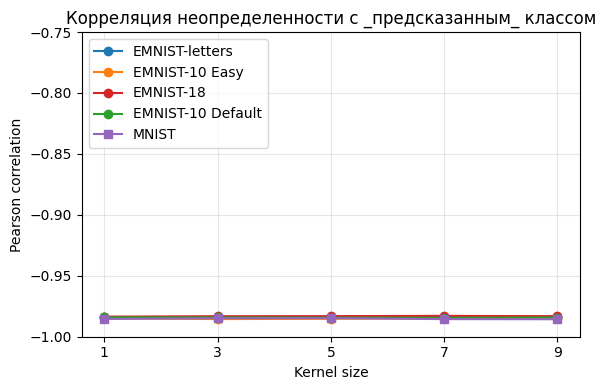

In [21]:
colors = {'E': 'C0', 'E10E': 'C1', 'E10D': 'C2', 'E18': 'C3', 'M': 'C4'}
markers = {'E': 'o', 'M': 's'}

fig, ax = plt.subplots(figsize=(6, 4), sharey=True)

ax.plot(kernel_sizes, emnist_correlations_pred, marker=markers['E'], color=colors['E'], label='EMNIST-letters')
ax.plot(kernel_sizes, emnist10_correlations_pred, marker=markers['E'], color=colors['E10E'], label='EMNIST-10 Easy')
ax.plot(kernel_sizes, emnist18_correlations_pred, marker=markers['E'], color=colors['E18'], label='EMNIST-18')
ax.plot(kernel_sizes, emnist10_def_correlations_pred, marker=markers['E'], color=colors['E10D'], label='EMNIST-10 Default')
ax.plot(kernel_sizes, mnist_correlations_pred, marker=markers['M'], color=colors['M'], label='MNIST')
ax.set_title('Корреляция неопределенности с _предсказанным_ классом')
ax.set_xticks(kernel_sizes)
ax.set_xlabel("Kernel size")
ax.set_ylabel("Pearson correlation")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=-1.0, top=-0.75)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()



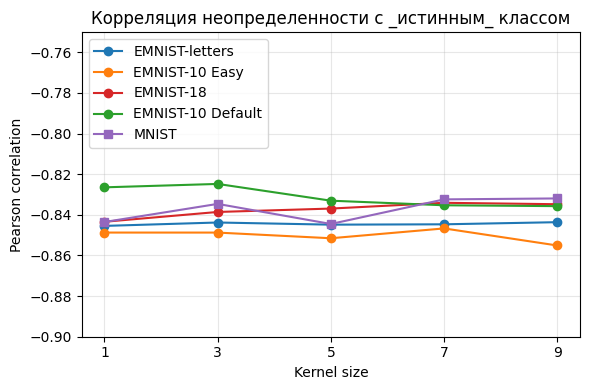

In [19]:
colors = {'E': 'C0', 'E10E': 'C1', 'E10D': 'C2', 'E18': 'C3', 'M': 'C4'}
markers = {'E': 'o', 'M': 's'}

fig, ax = plt.subplots(figsize=(6, 4), sharey=True)

ax.plot(kernel_sizes, emnist_correlations_true, marker=markers['E'], color=colors['E'], label='EMNIST-letters')
ax.plot(kernel_sizes, emnist10_correlations_true, marker=markers['E'], color=colors['E10E'], label='EMNIST-10 Easy')
ax.plot(kernel_sizes, emnist18_correlations_true, marker=markers['E'], color=colors['E18'], label='EMNIST-18')
ax.plot(kernel_sizes, emnist10_def_correlations_true, marker=markers['E'], color=colors['E10D'], label='EMNIST-10 Default')
ax.plot(kernel_sizes, mnist_correlations_true, marker=markers['M'], color=colors['M'], label='MNIST')
ax.set_title('Корреляция неопределенности с _истинным_ классом')
ax.set_xticks(kernel_sizes)
ax.set_xlabel("Kernel size")
ax.set_ylabel("Pearson correlation")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=-0.9,top=-0.75)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

